# Evaluation de la Variabilité liée à la Seed
Ce notebook entraîne plusieurs fois un modèle (ex: RandomForest) sur des données simples avec des seeds différentes pour observer l'impact direct sur `evaluation_scoring`, le score aggregé (`agg`), et les **composantes des scores k** (min_k, med_k, neg_k, viol_k).


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Ajout des chemins
sys.path.append(os.path.abspath('forecasting_models/sklearn'))
sys.path.append(os.path.abspath('.'))

from score import evaluate_metrics, fit_spline_mu, PASSAGES
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# 1. Génération de données synthétiques s'approchant de nos classes (0 à 4)
X, y = make_regression(n_samples=2000, n_features=15, noise=0.5, random_state=42)
y = np.clip(np.round((y - y.min()) / (y.max() - y.min()) * 4), 0, 4) # Classes 0 à 4

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fausses dates et zones
dates_test = np.ones_like(y_test)
zones_test = np.ones_like(y_test)

print(f"Distribution des classes test : {np.unique(y_test, return_counts=True)}")

def compute_geometric_agg(raw_dict, ref_scores=None):
    EPS = 1e-6
    if ref_scores is None:
        ref_scores = {k: 0.0 for k in ['score_k1', 'score_k2', 'score_k3', 'score_k4', 'recall', 'score_min_class']}
        
    def _u(sk, raw_key):
        skr = float(ref_scores.get(raw_key, 0.0))
        denom = max(abs(skr) + EPS, 0.1)
        return (np.tanh((sk - skr) / denom) + 1.0) / 2.0

    pairs = [(float(raw_dict.get(f'score_k{k}', 0.0)), f'score_k{k}') for k in [1, 2, 3, 4]]
    pairs.append((float(raw_dict.get('recall', 0.0)), 'recall'))
    pairs.append((float(raw_dict.get('score_min_class', 0.0)), 'score_min_class'))
    
    u_vals = [_u(sk, key) for sk, key in pairs]
    U = np.exp(np.mean(np.log(np.array(u_vals) + EPS)))
    agg = float(2.0 * U - 1.0)
    return agg

def evaluation_scoring_components(ypred, ytrue, dates, zones, df_spline=5, min_n=1, min_k=0, min_gain=[0.0]*4, n0=100):
    df = pd.DataFrame({"score": ypred, "Y": ytrue, "date": dates, "zone": zones})
    df["_lvl"] = df["score"].clip(0, 4).astype(int)
    lvl_counts = df["_lvl"].value_counts().to_dict()
    sigma = df["Y"].std()
    if sigma < 1e-6 or np.isnan(sigma): sigma = 1.0
    
    mu, fit = fit_spline_mu(df, df_spline=df_spline)
    
    components = {}
    score_adj_k = {}
    
    if all(np.isnan(list(mu.values()))):
        return 0, 0, {}, {}, 0
        
    w_avg, w_min, w_neg, w_viol = 1.0, 1.0, 1.0, 1.0
    
    for k in [1, 2, 3, 4]:
        pairs = PASSAGES.get(k, [])
        deltas = []
        coverage = 0
        min_g = min_gain if isinstance(min_gain, (int, float)) else min_gain[k-1]
        
        for (a, b) in pairs:
            n_a = lvl_counts.get(a, 0)
            n_b = lvl_counts.get(b, 0)
            if n_a >= min_n and n_b >= min_n:
                deltas.append(mu[b] - (mu[a] + min_g))
                coverage += min(n_a, n_b)
                
        if coverage < min_k or len(deltas) == 0:
            score_adj_k[k] = 0.0
            components[k] = {'med': 0.0, 'min': 0.0, 'neg': 0.0, 'viol': 0.0}
            continue
            
        deltas_std = np.array(deltas) / sigma
        avg_delta = np.median(deltas_std) 
        min_delta = np.min(deltas_std)
        neg_mass = np.mean(np.clip(-deltas_std, 0.0, None))
        viol_rt = np.mean(deltas_std < 0.0)
        
        score = ((w_avg * avg_delta + w_min * min_delta) / 2 - w_neg * neg_mass * (1 + w_viol * viol_rt))
        score = np.clip(score, -1e6, 1e6) if not np.isnan(score) else 0.0
        
        score_adj_k[k] = score
        components[k] = {'med': avg_delta, 'min': min_delta, 'neg': neg_mass, 'viol': viol_rt}

    score_low = score_adj_k[1] + score_adj_k[2]
    score_high = score_adj_k[3] + score_adj_k[4]
    
    c_min = float(np.min(np.round(ypred)))
    score_min_class = -c_min * 2 + 1 if np.sum(ytrue == 0) > n0 else 0.0
    
    return score_high, score_low, components, score_adj_k, score_min_class


Distribution des classes test : (array([1., 2., 3., 4.]), array([ 52, 346, 194,   8]))


In [13]:
n_runs = 30
results = []

print("Entraînement des modèles et extraction des composantes...")
for seed in range(n_runs):
    model = RandomForestRegressor(random_state=seed, max_depth=10, n_estimators=50)
    model.fit(X_train, y_train)
    
    y_pred_cont = model.predict(X_test)
    y_pred_discrete = np.round(y_pred_cont).astype(int)
    
    metrics = evaluate_metrics(y_test, y_pred_discrete, dates_test, zones_test)
    agg = compute_geometric_agg(metrics)
    
    # Utilisation de notre fonction personnalisée pour récuperer les dict de composantes
    score_high, score_low, components, score_adj_k, score_min_class = evaluation_scoring_components(
        y_pred_cont, y_test, dates_test, zones_test
    )
    
    res_dict = {
        'seed': seed,
        'agg': agg,
        'score_high': score_high,
        'score_low': score_low,
        'score_k1': score_adj_k.get(1, 0),
        'score_min_class': score_min_class,
        'recall': metrics.get('recall', np.nan)
    }
    
    # Intégration des composantes pour K=1 (par exemple, pour afficher un plot propre)
    for k in [1, 2, 3, 4]:
        c = components.get(k, {'med':0, 'min':0, 'neg':0, 'viol':0})
        res_dict[f'med_k{k}'] = c['med']
        res_dict[f'min_k{k}'] = c['min']
        res_dict[f'neg_k{k}'] = c['neg']
        res_dict[f'viol_k{k}'] = c['viol']
        
    results.append(res_dict)

df_res = pd.DataFrame(results)
display(df_res.drop(columns=['seed']).describe().round(4))


Entraînement des modèles et extraction des composantes...


,agg,score_high,score_low,score_k1,score_min_class,recall,med_k1,min_k1,neg_k1,viol_k1,...,neg_k2,viol_k2,med_k3,min_k3,neg_k3,viol_k3,med_k4,min_k4,neg_k4,viol_k4
count,30.0000,30.0000,30.0000,30.0000,30.0,30.0,30.0000,30.0000,30.0,30.0,...,30.0,30.0,30.0000,30.0000,30.0,30.0,30.0,30.0,30.0,30.0
mean,0.4142,0.3429,6.6057,2.1012,0.0,1.0,2.2726,1.9297,0.0,0.0,...,0.0,0.0,0.3429,0.3429,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0000,1.3051,0.6016,0.1760,0.0,0.0,0.1691,0.2344,0.0,0.0,...,0.0,0.0,1.3051,1.3051,0.0,0.0,0.0,0.0,0.0,0.0
min,0.4142,0.0000,4.8825,1.5001,0.0,1.0,1.9883,1.0099,0.0,0.0,...,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.4142,0.0000,6.3253,2.0589,0.0,1.0,2.1314,1.9677,0.0,0.0,...,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.4142,0.0000,6.6729,2.1347,0.0,1.0,2.2776,1.9895,0.0,0.0,...,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.4142,0.0000,6.9103,2.1937,0.0,1.0,2.3693,2.0104,0.0,0.0,...,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,0.4142,5.1602,7.3938,2.2825,0.0,1.0,2.5578,2.0825,0.0,0.0,...,0.0,0.0,5.1602,5.1602,0.0,0.0,0.0,0.0,0.0,0.0


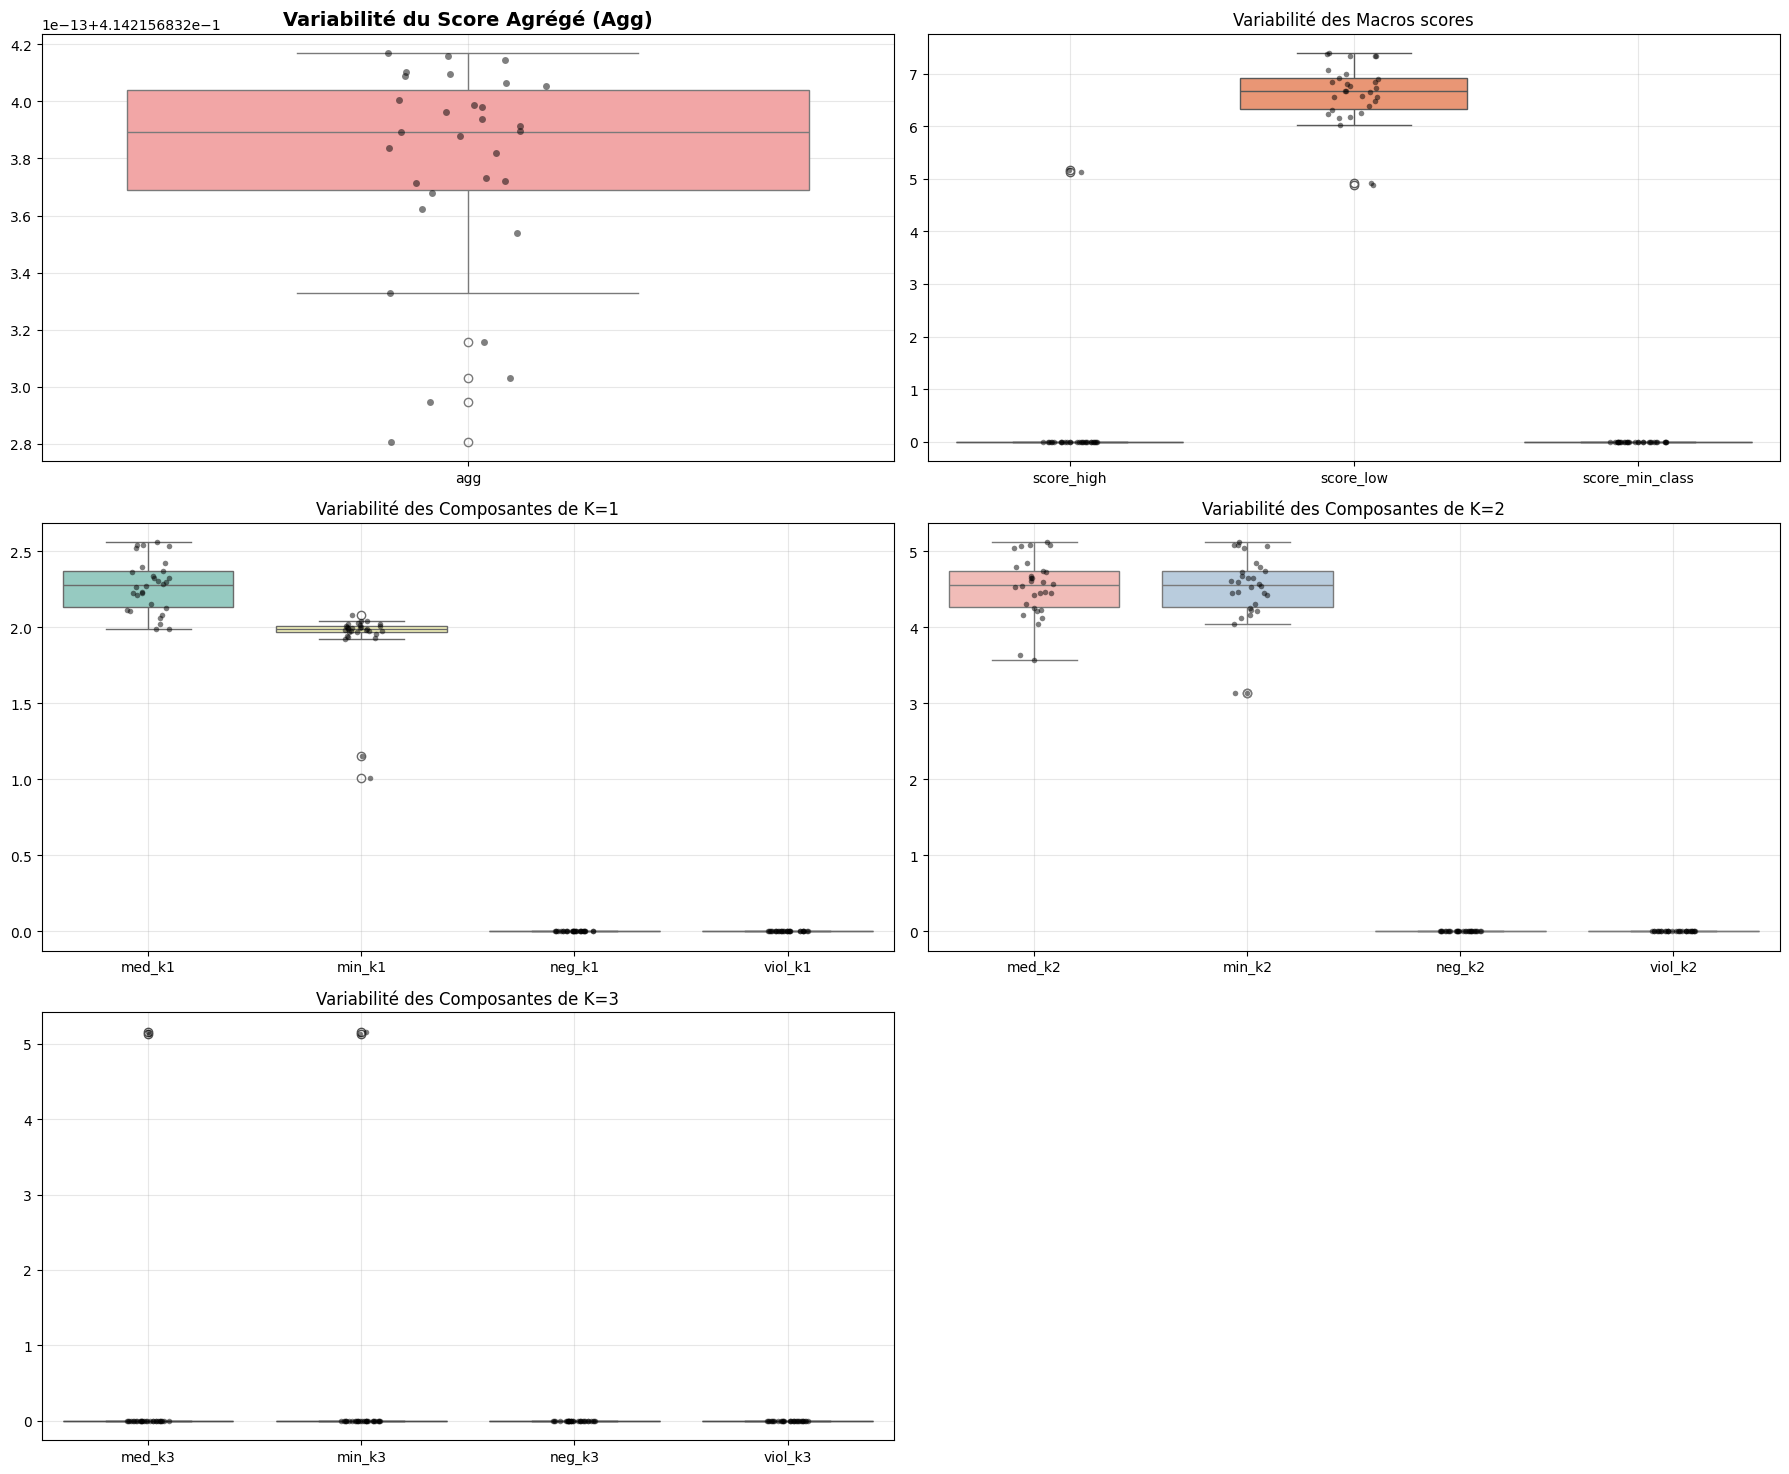

Écart-type relatif (Coefficient de Variation) des scores (%):
 agg                  0.00
score_high         380.56
score_low            9.11
score_k1             8.38
score_min_class       NaN
recall               0.00
med_k1               7.44
min_k1              12.15
neg_k1                NaN
viol_k1               NaN
med_k2               8.66
min_k2              10.58
neg_k2                NaN
viol_k2               NaN
med_k3             380.56
min_k3             380.56
neg_k3                NaN
viol_k3               NaN
med_k4                NaN
min_k4                NaN
neg_k4                NaN
viol_k4               NaN
dtype: float64


In [14]:
fig = plt.figure(figsize=(18, 15))
from matplotlib.gridspec import GridSpec
gs = GridSpec(3, 2, figure=fig)

# 1. Plot agg tout seul, bien visible en haut à gauche
ax_agg = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df_res[['agg']], ax=ax_agg, palette=["#FF9999"])
sns.stripplot(data=df_res[['agg']], ax=ax_agg, color='black', alpha=0.5, size=5)
ax_agg.set_title('Variabilité du Score Agrégé (Agg)', fontsize=14, fontweight='bold')
ax_agg.grid(True, alpha=0.3)

# 2. Les macros scores (high, low, min_class) en haut à droite
ax_macro = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df_res[['score_high', 'score_low', 'score_min_class']], ax=ax_macro, palette="Set2")
sns.stripplot(data=df_res[['score_high', 'score_low', 'score_min_class']], ax=ax_macro, color='black', alpha=0.5, size=4)
ax_macro.set_title('Variabilité des Macros scores')
ax_macro.grid(True, alpha=0.3)

# 3. Focus sur K=1
ax_k1 = fig.add_subplot(gs[1, 0])
k1_cols = ['med_k1', 'min_k1', 'neg_k1', 'viol_k1']
sns.boxplot(data=df_res[k1_cols], ax=ax_k1, palette="Set3")
sns.stripplot(data=df_res[k1_cols], ax=ax_k1, color='black', alpha=0.5, size=4)
ax_k1.set_title('Variabilité des Composantes de K=1')
ax_k1.grid(True, alpha=0.3)

# 4. Focus sur K=2
ax_k2 = fig.add_subplot(gs[1, 1])
k2_cols = ['med_k2', 'min_k2', 'neg_k2', 'viol_k2']
sns.boxplot(data=df_res[k2_cols], ax=ax_k2, palette="Pastel1")
sns.stripplot(data=df_res[k2_cols], ax=ax_k2, color='black', alpha=0.5, size=4)
ax_k2.set_title('Variabilité des Composantes de K=2')
ax_k2.grid(True, alpha=0.3)

# 5. Focus sur K=3
ax_k3 = fig.add_subplot(gs[2, 0])
k3_cols = ['med_k3', 'min_k3', 'neg_k3', 'viol_k3']
sns.boxplot(data=df_res[k3_cols], ax=ax_k3, palette="autumn")
sns.stripplot(data=df_res[k3_cols], ax=ax_k3, color='black', alpha=0.5, size=4)
ax_k3.set_title('Variabilité des Composantes de K=3')
ax_k3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cv = (df_res.drop(columns=['seed']).std() / df_res.drop(columns=['seed']).mean().abs()) * 100
print("Écart-type relatif (Coefficient de Variation) des scores (%):\n", cv.round(2))
